In [6]:
import os
import random
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.1


In [2]:
# Hiperparâmetros
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 30  # mais épocas, pois o modelo agora é estável
LEARNING_RATE = 0.0005  # menor, pra treino mais suave

# Caminhos
BASE_DIR = Path("../Dados")
TREINO_DIR = BASE_DIR / "Treino"
VALIDACAO_DIR = BASE_DIR / "Validacao"
TESTE_DIR = BASE_DIR / "Teste"

MODELOS_DIR = Path("../models")
REPORTS_DIR = Path("../reports")

print(f"Imagem: {IMG_SIZE} | Batch: {BATCH_SIZE} | Épocas máx: {EPOCHS} | LR: {LEARNING_RATE}")

Imagem: (128, 128) | Batch: 32 | Épocas máx: 30 | LR: 0.0005


In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TREINO_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VALIDACAO_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TESTE_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["nowildfire", "wildfire"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"\nClasses: {train_ds.class_names}")

Found 30249 files belonging to 2 classes.


2026-06-02 10:20:46.803677: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-06-02 10:20:46.803712: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 10:20:46.803720: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780406446.803752 1833684 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780406446.803784 1833684 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 6300 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.

Classes: ['nowildfire', 'wildfire']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

# NÃO normalizamos aqui — a normalização será uma camada do modelo (Rescaling)
# Apenas cache + prefetch
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Pipelines prontos")

Pipelines prontos


In [9]:
# Data augmentation: aplica transformações aleatórias apenas em treino
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")

print("Augmentation configurada:")
print("  - Flip horizontal e vertical")
print("  - Rotação aleatória até 20%")
print("  - Zoom aleatório até 15%")
print("  - Contraste aleatório até 10%")

Augmentation configurada:
  - Flip horizontal e vertical
  - Rotação aleatória até 20%
  - Zoom aleatório até 15%
  - Contraste aleatório até 10%


In [10]:
def criar_modelo_avancado(input_shape=(128, 128, 3)):
    """
    Modelo CNN Avançado com:
    - Rescaling (normalização como camada)
    - Data Augmentation integrado
    - 4 blocos Conv2D (32 → 64 → 128 → 256)
    - BatchNormalization após cada Conv2D
    - Dropout progressivo
    - GlobalAveragePooling em vez de Flatten
    """
    modelo = models.Sequential([
        layers.Input(shape=input_shape),

        # Augmentation + normalização
        data_augmentation,
        layers.Rescaling(1.0/255),

        # Bloco 1
        layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Bloco 2
        layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 3
        layers.Conv2D(128, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Bloco 4
        layers.Conv2D(256, (3, 3), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        # Classificador (sem Flatten — usa GAP)
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ], name="ModeloAvancado")

    return modelo

modelo_avancado = criar_modelo_avancado()
modelo_avancado.summary()

Model: "ModeloAvancado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             

 Total params: 423,265 (1.61 MB)

 Trainable params: 422,049 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [12]:
modelo_avancado.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("Modelo compilado")

Modelo compilado


In [14]:
checkpoint = callbacks.ModelCheckpoint(
    filepath=MODELOS_DIR / "modelo_avancado_melhor.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

print("Callbacks configurados:")
print("  - ModelCheckpoint (salva melhor modelo por val_accuracy)")
print("  - EarlyStopping (paciência 7 épocas)")
print("  - ReduceLROnPlateau (reduz LR pela metade após 3 épocas sem melhora)")

Callbacks configurados:
  - ModelCheckpoint (salva melhor modelo por val_accuracy)
  - EarlyStopping (paciência 7 épocas)
  - ReduceLROnPlateau (reduz LR pela metade após 3 épocas sem melhora)


In [15]:
inicio = time.time()

historico_avancado = modelo_avancado.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1,
)

tempo_total = (time.time() - inicio) / 60
print(f"\n⏱️ Tempo total: {tempo_total:.2f} minutos")

Epoch 1/30


2026-06-02 10:24:03.961410: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.9094 - loss: 0.2445
Epoch 1: val_accuracy improved from None to 0.93714, saving model to ../models/modelo_avancado_melhor.keras

Epoch 1: finished saving model to ../models/modelo_avancado_melhor.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 105s 105ms/step - accuracy: 0.9209 - loss: 0.2106 - val_accuracy: 0.9371 - val_loss: 0.2020 - learning_rate: 5.0000e-04
Epoch 2/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9343 - loss: 0.1743
Epoch 2: val_accuracy improved from 0.93714 to 0.94413, saving model to ../models/modelo_avancado_melhor.keras

Epoch 2: finished saving model to ../models/modelo_avancado_melhor.keras
946/946 ━━━━━━━━━━━━━━━━━━━━ 96s 102ms/step - accuracy: 0.9369 - loss: 0.1691 - val_accuracy: 0.9441 - val_loss: 0.1653 - learning_rate: 5.0000e-04
Epoch 3/30
946/946 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.9398 - loss: 0.1605
Epoch 3: val_accuracy improved from 0.94413 to 0.95492, saving model to ../models/mod

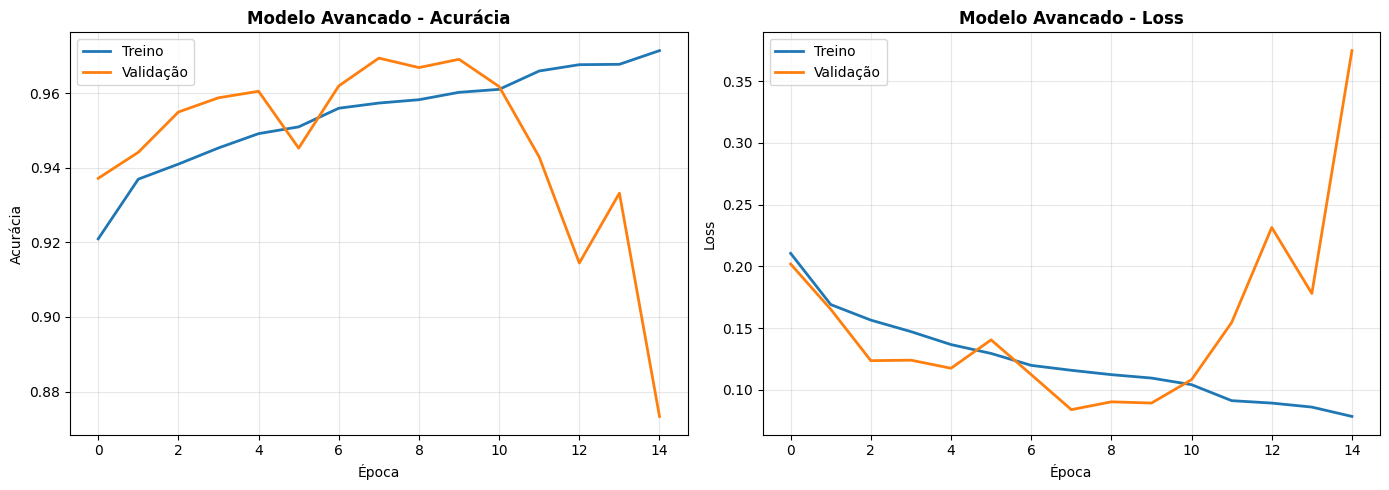

In [16]:
def plotar_historico(historico, nome_modelo):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(historico.history["accuracy"], label="Treino", linewidth=2)
    axes[0].plot(historico.history["val_accuracy"], label="Validação", linewidth=2)
    axes[0].set_title(f"{nome_modelo} - Acurácia", fontweight="bold")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Acurácia")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(historico.history["loss"], label="Treino", linewidth=2)
    axes[1].plot(historico.history["val_loss"], label="Validação", linewidth=2)
    axes[1].set_title(f"{nome_modelo} - Loss", fontweight="bold")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"{nome_modelo.lower().replace(' ', '_')}_curvas.png", dpi=100, bbox_inches="tight")
    plt.show()

plotar_historico(historico_avancado, "Modelo Avancado")

In [17]:
print("Avaliando Modelo Avançado no conjunto de TESTE...\n")
test_loss, test_acc = modelo_avancado.evaluate(test_ds, verbose=1)

print(f"\n📊 RESULTADOS — Modelo Avançado")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Salva métricas
metricas_avancado = {
    "modelo": "ModeloAvancado",
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "epochs_treinadas": len(historico_avancado.history["loss"]),
    "tempo_minutos": tempo_total,
    "historico": {k: [float(v) for v in vals] for k, vals in historico_avancado.history.items()},
}

with open(REPORTS_DIR / "metricas_avancado.json", "w") as f:
    json.dump(metricas_avancado, f, indent=2)

print(f"\n✅ Métricas salvas em reports/metricas_avancado.json")


Avaliando Modelo Avançado no conjunto de TESTE...

197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9730 - loss: 0.0701

📊 RESULTADOS — Modelo Avançado
   Test Loss:     0.0701
   Test Accuracy: 0.9730 (97.30%)

✅ Métricas salvas em reports/metricas_avancado.json
